In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Setup

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb
from kaggle_secrets import UserSecretsClient
wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))

DATA = "/kaggle/input/competitions/smart-mcq-solver-challenge"
OPTIONS = ["A", "B", "C", "D", "E"]
device = "cuda" if torch.cuda.is_available() else "cpu"

train = pd.read_csv(f"{DATA}/train.csv")
test  = pd.read_csv(f"{DATA}/test.csv")

train["label"] = train["answer"].map({c: i for i, c in enumerate(OPTIONS)})

print("train:", train.shape, "| test:", test.shape)
train.head(2)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ishankgpt02 (ishankgpt02-na) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


train: (2000, 9) | test: (500, 7)


,id,prompt,A,B,C,D,E,answer,label
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,1
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A,0


# Metric - MAP@3

In [3]:
def map3(scores, labels):
    order = np.argsort(-scores, axis=1)   
    total = 0.0
    for row, correct in zip(order, labels):
        rank = int(np.where(row == correct)[0][0])
        if rank < 3:
            total += 1.0 / (rank + 1)
    return total / len(labels)

demo = np.array([[9, 1, 0, 0, 0]])
print("demo map3:", map3(demo, np.array([0])))

demo map3: 1.0


# EDA

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


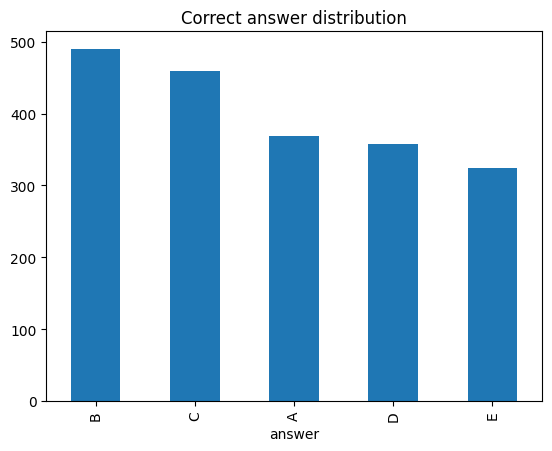

In [4]:
print(train["answer"].value_counts())
train["answer"].value_counts().plot(kind="bar", title="Correct answer distribution");

In [5]:
train["prompt_len"] = train["prompt"].str.split().str.len()
print("Average prompt words:", round(train["prompt_len"].mean(), 1))
for o in OPTIONS:
    print(f"Option {o} avg words:", round(train[o].str.split().str.len().mean(), 1))

Average prompt words: 18.1
Option A avg words: 26.1
Option B avg words: 26.5
Option C avg words: 26.5
Option D avg words: 26.0
Option E avg words: 26.2


## Key Finding - Distractor

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

texts, flags = [], []
for _, r in train.iterrows():
    for o in OPTIONS:
        texts.append(str(r[o]))
        flags.append(1 if r["answer"] == o else 0)

vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X = vec.fit_transform(texts)
Xtr, Xva, ytr, yva = train_test_split(X, np.array(flags), test_size=0.2,
                                      random_state=42, stratify=flags)
clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
auc = roc_auc_score(yva, clf.predict_proba(Xva)[:, 1])
print(f"Distractor-detection AUC = {auc:.4f}")

Distractor-detection AUC = 0.9789


In [7]:
names = np.array(vec.get_feature_names_out())
coef = clf.coef_[0]
print("Distractor words:", list(names[np.argsort(coef)[:10]]))

Distractor words: ['not', 'no', 'measure the', 'classical', 'measure', 'is', 'is measure', 'measure of', 'in the', 'gravitational']


# Models

## Model A - Tfidf + Logistic Regression

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold

def make_text(df):
    return (df["prompt"].astype(str) + " A: " + df["A"].astype(str)
            + " B: " + df["B"].astype(str) + " C: " + df["C"].astype(str)
            + " D: " + df["D"].astype(str) + " E: " + df["E"].astype(str))

X_text = make_text(train)
y = train["label"].values

In [9]:
run = wandb.init(entity="ishankgpt02-na", project="23f1002033-t22026",
                 name="final-tfidf-lr-cv")
wandb.define_metric("fold")
wandb.define_metric("cv/*", step_metric="fold")

skf = StratifiedKFold(5, shuffle=True, random_state=42)
cv_scores = []
for fold, (tr_i, va_i) in enumerate(skf.split(X_text, y), start=1):
    m = Pipeline([("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                            stop_words="english")),
                  ("clf", LogisticRegression(max_iter=1000))])
    m.fit(X_text.iloc[tr_i], y[tr_i])
    proba = m.predict_proba(X_text.iloc[va_i])
    fold_map3 = map3(proba, y[va_i])
    cv_scores.append(fold_map3)
    wandb.log({"cv/fold_map@3": fold_map3, "fold": fold})   
    print(f"fold {fold}: MAP@3 = {fold_map3:.4f}")

print("CV MAP@3 mean:", round(np.mean(cv_scores), 4))
run.finish()

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260719_144227-evg2wmag
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run final-tfidf-lr-cv
wandb: ⭐️ View project at https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: 🚀 View run at https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/evg2wmag


fold 1: MAP@3 = 1.0000
fold 2: MAP@3 = 1.0000
fold 3: MAP@3 = 1.0000
fold 4: MAP@3 = 1.0000


wandb: updating run metadata


fold 5: MAP@3 = 1.0000
CV MAP@3 mean: 1.0


wandb: uploading history steps 0-4, summary, console lines 0-5
wandb: 
wandb: Run history:
wandb: cv/fold_map@3 ▁▁▁▁▁
wandb:          fold ▁▃▅▆█
wandb: 
wandb: Run summary:
wandb: cv/fold_map@3 1
wandb:          fold 5
wandb: 
wandb: 🚀 View run final-tfidf-lr-cv at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/evg2wmag
wandb: ⭐️ View project at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260719_144227-evg2wmag/logs


## Model B - BiLSTM

In [10]:
import re
from collections import Counter

def tokenize(t):
    return re.findall(r"[a-z0-9]+", str(t).lower())

counter = Counter()
for col in ["prompt"] + OPTIONS:
    for t in train[col]:
        counter.update(tokenize(t))

PAD, UNK = 0, 1
vocab = {"<pad>": PAD, "<unk>": UNK}
for w, c in counter.items():
    if c >= 2:                      
        vocab[w] = len(vocab)
print("Vocab size:", len(vocab))

Vocab size: 2972


In [11]:
MAX_LEN = 64

def encode(text):
    ids = [vocab.get(w, UNK) for w in tokenize(text)][:MAX_LEN]
    return ids + [PAD] * (MAX_LEN - len(ids))     

print("example:", encode("What is light-ion fusion?")[:10])

example: [7, 8, 25, 26, 27, 0, 0, 0, 0, 0]


In [12]:
from torch.utils.data import Dataset, DataLoader

class MCQData(Dataset):
    def __init__(self, df, has_label=True):
        self.p = [encode(t) for t in df["prompt"]]
        self.o = [[encode(str(r[c])) for c in OPTIONS] for _, r in df.iterrows()]
        self.y = df["label"].tolist() if has_label else [0] * len(df)
    def __len__(self):
        return len(self.p)
    def __getitem__(self, i):
        return (torch.tensor(self.p[i]), torch.tensor(self.o[i]),
                torch.tensor(self.y[i]))

tr_df, va_df = train_test_split(train, test_size=0.1, random_state=42,
                                stratify=train["label"])
tr_loader = DataLoader(MCQData(tr_df), batch_size=32, shuffle=True)
va_loader = DataLoader(MCQData(va_df), batch_size=64)
te_loader = DataLoader(MCQData(test, has_label=False), batch_size=64)
y_val = va_df["label"].to_numpy()          
print("train batches:", len(tr_loader), "| y_val:", y_val.shape)

train batches: 57 | y_val: (200,)


In [13]:
lr_split = Pipeline([("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                               stop_words="english")),
                     ("clf", LogisticRegression(max_iter=1000))])
lr_split.fit(make_text(tr_df), tr_df["label"].values)
lr_proba = lr_split.predict_proba(make_text(va_df))     

lr_final = Pipeline([("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                               stop_words="english")),
                     ("clf", LogisticRegression(max_iter=1000))])
lr_final.fit(make_text(train), train["label"].values)
print("lr_proba:", lr_proba.shape, "| lr_final fitted on", len(train), "rows")


lr_proba: (200, 5) | lr_final fitted on 2000 rows


In [14]:
class BiLSTMMatcher(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=True)
        self.scorer = nn.Sequential(
            nn.Linear(hidden * 2 * 4, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, 1))

    def encode(self, ids):                          
        emb = self.embedding(ids)                   
        out, _ = self.lstm(emb)                     
        mask = (ids != PAD).unsqueeze(-1).float()   
        return (out * mask).sum(1) / mask.sum(1).clamp(min=1)   

    def forward(self, prompt, options):             
        p = self.encode(prompt)                                 
        B, N, T = options.shape
        o = self.encode(options.view(B * N, T)).view(B, N, -1)  
        p = p.unsqueeze(1).expand(-1, N, -1)
        feat = torch.cat([p, o, p * o, (p - o).abs()], dim=-1)
        return self.scorer(feat).squeeze(-1)                    

model = BiLSTMMatcher(len(vocab)).to(device)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 775937


In [15]:

run = wandb.init(entity="ishankgpt02-na", project="23f1002033-t22026",
                 name="final-bilstm-training")
wandb.define_metric("step")
wandb.define_metric("train/*", step_metric="step")
wandb.define_metric("epoch")
wandb.define_metric("val/*", step_metric="epoch")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10 * len(tr_loader))
loss_fn = nn.CrossEntropyLoss()
gstep = 0

for epoch in range(1, 11):
    # TRAIN
    model.train()
    ep_loss = 0
    for prompt, options, yb in tr_loader:
        prompt, options, yb = prompt.to(device), options.to(device), yb.to(device)
        optimizer.zero_grad()               
        logits = model(prompt, options)     
        loss = loss_fn(logits, yb)
        loss.backward()                     
        optimizer.step()                    
        scheduler.step()                    
        ep_loss += loss.item()
        gstep += 1
        wandb.log({"train/loss": loss.item(),
                   "train/lr": scheduler.get_last_lr()[0], "step": gstep})

    # VALIDATE
    model.eval()
    scores_all, y_all = [], []
    with torch.no_grad():                   
        for prompt, options, yb in va_loader:
            logits = model(prompt.to(device), options.to(device))
            scores_all.append(logits.cpu().numpy())
            y_all.append(yb.numpy())
    S, Y = np.concatenate(scores_all), np.concatenate(y_all)
    v_map3 = map3(S, Y)
    v_acc = float((S.argmax(1) == Y).mean())
    wandb.log({"val/map@3": v_map3, "val/accuracy": v_acc,
               "val/loss_epoch_train": ep_loss/len(tr_loader), "epoch": epoch})
    print(f"epoch {epoch:2d} | loss {ep_loss/len(tr_loader):.4f} | "
          f"val MAP@3 {v_map3:.4f} | val acc {v_acc:.4f}")

run.finish()

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260719_144243-6445wvkb
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run final-bilstm-training
wandb: ⭐️ View project at https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: 🚀 View run at https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/6445wvkb


epoch  1 | loss 1.2541 | val MAP@3 0.9217 | val acc 0.8750
epoch  2 | loss 0.2055 | val MAP@3 0.9933 | val acc 0.9900
epoch  3 | loss 0.0393 | val MAP@3 1.0000 | val acc 1.0000
epoch  4 | loss 0.0125 | val MAP@3 1.0000 | val acc 1.0000
epoch  5 | loss 0.0014 | val MAP@3 1.0000 | val acc 1.0000
epoch  6 | loss 0.0007 | val MAP@3 1.0000 | val acc 1.0000
epoch  7 | loss 0.0004 | val MAP@3 1.0000 | val acc 1.0000
epoch  8 | loss 0.0004 | val MAP@3 1.0000 | val acc 1.0000
epoch  9 | loss 0.0002 | val MAP@3 1.0000 | val acc 1.0000


wandb: updating run metadata


epoch 10 | loss 0.0003 | val MAP@3 1.0000 | val acc 1.0000


wandb: uploading history steps 0-579, summary, console lines 0-9
wandb: 
wandb: Run history:
wandb:                epoch ▁▂▃▃▄▅▆▆▇█
wandb:                 step ▁▁▁▁▁▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█
wandb:           train/loss █▇▅▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:             train/lr █████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
wandb:         val/accuracy ▁▇████████
wandb: val/loss_epoch_train █▂▁▁▁▁▁▁▁▁
wandb:            val/map@3 ▁▇████████
wandb: 
wandb: Run summary:
wandb:                epoch 10
wandb:                 step 570
wandb:           train/loss 0.00021
wandb:             train/lr 0
wandb:         val/accuracy 1
wandb: val/loss_epoch_train 0.00029
wandb:            val/map@3 1
wandb: 
wandb: 🚀 View run final-bilstm-training at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/6445wvkb
wandb: ⭐️ View project at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find l

## Model C - RAG Pipeline

In [16]:
!pip install -q faiss-cpu
import faiss
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import pipeline as hf_pipeline

DEV = 0 if torch.cuda.is_available() else -1

kb = [str(r[r["answer"]]) for _, r in train.iterrows()]

embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
kb_emb = embedder.encode(kb, normalize_embeddings=True,
                         show_progress_bar=True).astype("float32")
rag_index = faiss.IndexFlatIP(kb_emb.shape[1])
rag_index.add(kb_emb)

cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
reader = hf_pipeline("zero-shot-classification",
                     model="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli", device=DEV)
print("RAG ready. KB docs:", rag_index.ntotal)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 78.5 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

RAG ready. KB docs: 2000


In [17]:
RETRIEVE_K, CONTEXT_N = 10, 3

def rag_option_scores(question, option_texts, exclude=None):
    q = embedder.encode([str(question)], normalize_embeddings=True).astype("float32")
    _, I = rag_index.search(q, RETRIEVE_K + (1 if exclude is not None else 0))
    cand = [int(i) for i in I[0] if i != exclude][:RETRIEVE_K]
    ce = cross_encoder.predict([[str(question), kb[i]] for i in cand])
    best = [cand[j] for j in np.argsort(ce)[::-1][:CONTEXT_N]]
    context = " ".join(kb[i] for i in best)
    res = reader(f"Context: {context} Question: {question}",
                 candidate_labels=option_texts)
    d = dict(zip(res["labels"], res["scores"]))
    return np.array([d[t] for t in option_texts])

In [18]:
from tqdm.auto import tqdm

run = wandb.init(entity="ishankgpt02-na", project="23f1002033-t22026",
                 name="final-rag-context-sweep")
wandb.define_metric("context_n")
wandb.define_metric("rag/*", step_metric="context_n")

N_SWEEP = 100   
def rag_with_n(question, option_texts, n, exclude=None):
    q = embedder.encode([str(question)], normalize_embeddings=True).astype("float32")
    _, I = rag_index.search(q, RETRIEVE_K + (1 if exclude is not None else 0))
    cand = [int(i) for i in I[0] if i != exclude][:RETRIEVE_K]
    ce = cross_encoder.predict([[str(question), kb[i]] for i in cand])
    best = [cand[j] for j in np.argsort(ce)[::-1][:n]]
    context = " ".join(kb[i] for i in best)
    res = reader(f"Context: {context} Question: {question}", candidate_labels=option_texts)
    d = dict(zip(res["labels"], res["scores"]))
    return np.array([d[t] for t in option_texts])

for n in [1, 2, 3, 5]:
    sweep_scores = np.zeros((N_SWEEP, 5))
    for i in range(N_SWEEP):
        r = va_df.iloc[i]
        opts = [str(r[o]) for o in OPTIONS]
        sweep_scores[i] = rag_with_n(str(r["prompt"]), opts, n, exclude=r.name)
    sc = map3(sweep_scores, y_val[:N_SWEEP])
    print(f"context_n={n}: MAP@3={sc:.4f}")
    wandb.log({"rag/map@3": sc, "context_n": n})
run.finish()

rag_val = np.zeros((len(va_df), 5))
for i in tqdm(range(len(va_df)), desc="RAG on full validation"):
    r = va_df.iloc[i]
    opts = [str(r[o]) for o in OPTIONS]
    rag_val[i] = rag_option_scores(str(r["prompt"]), opts, exclude=r.name)
rag_map3 = map3(rag_val, y_val)
print("RAG-only val MAP@3:", round(rag_map3, 4))

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260719_144338-jdwqex2b
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run final-rag-context-sweep
wandb: ⭐️ View project at https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: 🚀 View run at https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/jdwqex2b
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


context_n=1: MAP@3=0.8750
context_n=2: MAP@3=0.8967
context_n=3: MAP@3=0.8950


wandb: updating run metadata


context_n=5: MAP@3=0.8950


wandb: uploading history steps 3-3, summary, console lines 4-4
wandb: 
wandb: Run history:
wandb: context_n ▁▃▅█
wandb: rag/map@3 ▁█▇▇
wandb: 
wandb: Run summary:
wandb: context_n 5
wandb: rag/map@3 0.895
wandb: 
wandb: 🚀 View run final-rag-context-sweep at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/jdwqex2b
wandb: ⭐️ View project at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260719_144338-jdwqex2b/logs


RAG on full validation:   0%|          | 0/200 [00:00<?, ?it/s]

RAG-only val MAP@3: 0.8933


## Modal D - Distractor Emsemble

In [19]:
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import KFold as _KFold
from scipy.stats import rankdata

def _opt_rows_df(df):
    tex, fl = [], []
    for _, r in df.iterrows():
        for o in OPTIONS:
            tex.append(str(r[o])); fl.append(1 if r["answer"] == o else 0)
    return tex, np.array(fl)

def _fit_bank(tex, fl):
    vw = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, sublinear_tf=True).fit(tex)
    vc = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                         max_features=50000, sublinear_tf=True).fit(tex)
    Xw, Xc = vw.transform(tex), vc.transform(tex)
    return {"vw": vw, "vc": vc,
            "lr_w":  LogisticRegression(max_iter=2000, C=10).fit(Xw, fl),
            "cnb_w": ComplementNB().fit(Xw, fl),
            "lr_c":  LogisticRegression(max_iter=2000, C=10).fit(Xc, fl)}

def ensemble_scores(bank, df):
    n = len(df); S = np.zeros((n, 5))
    for k in range(n):
        r = df.iloc[k]; ot = [str(r[o]) for o in OPTIONS]
        Xw = bank["vw"].transform(ot); Xc = bank["vc"].transform(ot)
        p1 = bank["lr_w"].predict_proba(Xw)[:, 1]
        p2 = bank["cnb_w"].predict_proba(Xw)[:, 1]
        p3 = bank["lr_c"].predict_proba(Xc)[:, 1]
        S[k] = rankdata(p1) + rankdata(p2) + rankdata(p3)   
    return S

run = wandb.init(entity="ishankgpt02-na", project="23f1002033-t22026",
                 name="final-distractor-ensemble")
kf = _KFold(5, shuffle=True, random_state=42)
ens_cv = []
for fold, (tri, vai) in enumerate(kf.split(np.arange(len(train))), start=1):
    tex, fl = _opt_rows_df(train.iloc[tri])
    Sv = ensemble_scores(_fit_bank(tex, fl), train.iloc[vai])
    fold_map3 = map3(Sv, train["label"].values[vai])
    ens_cv.append(fold_map3)
    wandb.log({"ens/fold_map@3": fold_map3, "fold": fold})
    print(f"fold {fold}: MAP@3 = {fold_map3:.4f}")
ens_map3_cv = float(np.mean(ens_cv))
print("Distractor-Ensemble CV MAP@3:", round(ens_map3_cv, 4),
      "+/-", round(float(np.std(ens_cv)), 4))
wandb.log({"ens/cv_map@3": ens_map3_cv})
run.finish()

bank_tr = _fit_bank(*_opt_rows_df(tr_df))
ens_val = ensemble_scores(bank_tr, va_df)

bank_full = _fit_bank(*_opt_rows_df(train))
ens_test = ensemble_scores(bank_full, test)
print("ens_val:", ens_val.shape, "| ens_test:", ens_test.shape)


wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260719_144509-k2o9pkwo
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run final-distractor-ensemble
wandb: ⭐️ View project at https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: 🚀 View run at https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/k2o9pkwo


fold 1: MAP@3 = 0.9950
fold 2: MAP@3 = 0.9962
fold 3: MAP@3 = 0.9925
fold 4: MAP@3 = 0.9925


wandb: updating run metadata


fold 5: MAP@3 = 1.0000
Distractor-Ensemble CV MAP@3: 0.9953 +/- 0.0028


wandb: uploading history steps 3-5, summary, console lines 3-5
wandb: 
wandb: Run history:
wandb:   ens/cv_map@3 ▁
wandb: ens/fold_map@3 ▃▄▁▁█
wandb:           fold ▁▃▅▆█
wandb: 
wandb: Run summary:
wandb:   ens/cv_map@3 0.99525
wandb: ens/fold_map@3 1
wandb:           fold 5
wandb: 
wandb: 🚀 View run final-distractor-ensemble at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/k2o9pkwo
wandb: ⭐️ View project at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260719_144509-k2o9pkwo/logs


ens_val: (200, 5) | ens_test: (500, 5)


# Model Comparison (accuray + macro-f1)

In [20]:
from sklearn.metrics import f1_score, accuracy_score
from itertools import product

def norm(m):
    m = np.clip(m, 1e-9, None)
    return m / m.sum(axis=1, keepdims=True)

P_lr, P_bi, P_rag = norm(lr_proba), norm(S), norm(rag_val)
P_ens = norm(ens_val)

candidates = {
    "TFIDF+LR": P_lr,
    "BiLSTM":   P_bi,
    "RAG":      P_rag,
    "Distractor-Ens": P_ens,
    "Ens+RAG (0.5/0.5)": 0.5*P_ens + 0.5*P_rag,
    "LR+RAG (0.5/0.5)": 0.5*P_lr + 0.5*P_rag,
    "BiLSTM+LR (0.5/0.5)": 0.5*P_bi + 0.5*P_lr,
    "BiLSTM+RAG (0.5/0.5)": 0.5*P_bi + 0.5*P_rag,
}
for a in [0.2, 0.4, 0.6]:
    for b in [0.2, 0.4]:
        c = round(1 - a - b, 2)
        if c > 0:
            candidates[f"3way ({a}/{b}/{c})"] = a*P_bi + b*P_lr + c*P_rag

rows = {}
for name, P in candidates.items():
    rows[name] = {"map3": round(map3(P, y_val), 4),
                  "acc": round(accuracy_score(y_val, P.argmax(1)), 4),
                  "f1_macro": round(f1_score(y_val, P.argmax(1), average="macro"), 4)}
comparison = pd.DataFrame(rows).T.sort_values("map3", ascending=False)
print(comparison)

FORCE_MODEL = "Distractor-Ens"   # <- winning model
BEST_NAME = FORCE_MODEL if FORCE_MODEL else comparison.index[0]
print("\nBest on validation:", comparison.index[0], "| Submitting with:", BEST_NAME)

                        map3    acc  f1_macro
TFIDF+LR              1.0000  1.000    1.0000
Distractor-Ens        1.0000  0.995    0.9950
3way (0.4/0.4/0.2)    1.0000  1.000    1.0000
3way (0.6/0.2/0.2)    1.0000  1.000    1.0000
BiLSTM+LR (0.5/0.5)   1.0000  1.000    1.0000
3way (0.2/0.4/0.4)    1.0000  1.000    1.0000
LR+RAG (0.5/0.5)      0.9925  0.985    0.9849
3way (0.4/0.2/0.4)    0.9900  0.980    0.9782
3way (0.2/0.2/0.6)    0.9750  0.950    0.9478
Ens+RAG (0.5/0.5)     0.9567  0.920    0.9201
BiLSTM+RAG (0.5/0.5)  0.9533  0.925    0.9222
RAG                   0.8933  0.830    0.8317
BiLSTM                0.7867  0.710    0.7422

Best on validation: TFIDF+LR | Submitting with: Distractor-Ens


In [21]:
run = wandb.init(entity="ishankgpt02-na", project="23f1002033-t22026",
                 name="final-model-comparison")

table = wandb.Table(columns=["model", "val_map@3", "val_accuracy", "val_f1_macro"])
for name in ["TFIDF+LR", "BiLSTM", "RAG", BEST_NAME]:
    m = rows[name]
    table.add_data(name, m["map3"], m["acc"], m["f1_macro"])

wandb.log({"model_comparison": table,
           "comparison/map3_bar": wandb.plot.bar(table, "model", "val_map@3",
                                                 title="Validation MAP@3 by model"),
           "comparison/f1_bar":   wandb.plot.bar(table, "model", "val_f1_macro",
                                                 title="Validation macro-F1 by model")})
run.finish()
print("Comparison table + bar charts logged to W&B")

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260719_144612-nbwexd7d
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run final-model-comparison
wandb: ⭐️ View project at https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: 🚀 View run at https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/nbwexd7d
wandb: updating run metadata; uploading artifact run-nbwexd7d-model_comparison; uploading summary
wandb: uploading artifact run-nbwexd7d-model_comparison
wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading media/table/model_comparison_0_99dd9c070f92d88cf0fd.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: 🚀 View run final-model-comparison at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026/runs/nbwexd7d
wandb: ⭐️ View project at: https://wandb.ai/ishankgpt02-na/23f1002033-t22026
wandb: Synced 4 W&B file(s), 1 media file(s), 2 artifact file(s) and 0 other file(s)

Comparison table + bar charts logged to W&B


# Submission

In [22]:
def get_test_components(best_name):
    comps = {}
    if "LR" in best_name or best_name == "TFIDF+LR":
        comps["lr"] = norm(lr_final.predict_proba(make_text(test)))
    if "BiLSTM" in best_name or "3way" in best_name:
        model.eval(); sc = []
        with torch.no_grad():
            for prompt, options, _ in te_loader:
                sc.append(model(prompt.to(device), options.to(device)).cpu().numpy())
        comps["bi"] = norm(np.concatenate(sc))
    if "RAG" in best_name or "3way" in best_name:
        from tqdm.auto import tqdm
        rt = np.zeros((len(test), 5))
        for i in tqdm(range(len(test)), desc="RAG on test"):
            r = test.iloc[i]
            rt[i] = rag_option_scores(str(r["prompt"]), [str(r[o]) for o in OPTIONS])
        comps["rag"] = norm(rt)
    return comps

comps = get_test_components(BEST_NAME)
comps["ens"] = norm(ens_test)

if BEST_NAME == "Distractor-Ens":
    P_final = comps["ens"]
elif BEST_NAME.startswith("Ens+RAG"):
    P_final = 0.5*comps["ens"] + 0.5*comps["rag"]
elif BEST_NAME == "TFIDF+LR":
    P_final = comps["lr"]
elif BEST_NAME == "BiLSTM":
    P_final = comps["bi"]
elif BEST_NAME == "RAG":
    P_final = comps["rag"]
elif BEST_NAME.startswith("LR+RAG"):
    P_final = 0.5*comps["lr"] + 0.5*comps["rag"]
elif BEST_NAME.startswith("BiLSTM+LR"):
    P_final = 0.5*comps["bi"] + 0.5*comps["lr"]
elif BEST_NAME.startswith("BiLSTM+RAG"):
    P_final = 0.5*comps["bi"] + 0.5*comps["rag"]
else:                                   
    a, b, c = [float(x) for x in BEST_NAME.split("(")[1].rstrip(")").split("/")]
    P_final = a*comps["bi"] + b*comps["lr"] + c*comps["rag"]

order = np.argsort(-P_final, axis=1)
preds = [" ".join(OPTIONS[j] for j in row[:3]) for row in order]
pd.DataFrame({"ID": test["id"], "Prediction": preds}).to_csv("submission.csv", index=False)
print(f"submission.csv saved using: {BEST_NAME}")

submission.csv saved using: Distractor-Ens


In [23]:
def save_sub(P, fname):
    order = np.argsort(-P, axis=1)
    preds = [" ".join(OPTIONS[j] for j in row[:3]) for row in order]
    pd.DataFrame({"ID": test["id"], "Prediction": preds}).to_csv(fname, index=False)
    print("saved:", fname)

P_lr_test = norm(lr_final.predict_proba(make_text(test)))
save_sub(P_lr_test, "submission_lr.csv")

model.eval(); sc = []
with torch.no_grad():
    for prompt, options, _ in te_loader:
        sc.append(model(prompt.to(device), options.to(device)).cpu().numpy())
P_bi_test = norm(np.concatenate(sc))
save_sub(P_bi_test, "submission_bilstm.csv")

from tqdm.auto import tqdm
rt = np.zeros((len(test), 5))
for i in tqdm(range(len(test)), desc="RAG on test"):
    r = test.iloc[i]
    rt[i] = rag_option_scores(str(r["prompt"]), [str(r[o]) for o in OPTIONS])
P_rag_test = norm(rt)
save_sub(P_rag_test, "submission_rag.csv")

save_sub(norm(ens_test), "submission_ens.csv")

save_sub(norm(ens_test), "submission.csv")

saved: submission_lr.csv
saved: submission_bilstm.csv


RAG on test:   0%|          | 0/500 [00:00<?, ?it/s]

saved: submission_rag.csv
saved: submission_ens.csv
saved: submission.csv
